fine-tuning secrets of optimization — Learning Rate Decay is a major key to boosting training stability and convergence. : Learning rate decay gradually reduces the learning rate to improve
convergence stability as training progresses

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Data
X = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 6, 8, 10])

# Parameters
theta0 = 0
theta1 = 0
alpha_0 = 0.1       # Initial learning rate
decay_rate = 0.05   # Decay constant
iterations = 100

m = len(X)

# Gradient Descent with learning rate decay
for t in range(1, iterations + 1):
    # Decaying learning rate
    alpha = alpha_0 / (1 + decay_rate * t)

    prediction = theta0 + theta1 * X
    error = prediction - y

    d_theta0 = (1/m) * np.sum(error)
    d_theta1 = (1/m) * np.sum(error * X)

    theta0 -= alpha * d_theta0
    theta1 -= alpha * d_theta1

    # Optional: print loss
    if t % 10 == 0:
        loss = np.mean((prediction - y) ** 2)
        print(f"Iteration {t}: Loss = {loss:.4f}, Learning Rate = {alpha:.4f}")

# Final results
print(f"\nFinal theta0: {theta0}, theta1: {theta1}")

Iteration 10: Loss = 0.0376, Learning Rate = 0.0667
Iteration 20: Loss = 0.0308, Learning Rate = 0.0500
Iteration 30: Loss = 0.0265, Learning Rate = 0.0400
Iteration 40: Loss = 0.0234, Learning Rate = 0.0333
Iteration 50: Loss = 0.0210, Learning Rate = 0.0286
Iteration 60: Loss = 0.0192, Learning Rate = 0.0250
Iteration 70: Loss = 0.0177, Learning Rate = 0.0222
Iteration 80: Loss = 0.0165, Learning Rate = 0.0200
Iteration 90: Loss = 0.0154, Learning Rate = 0.0182
Iteration 100: Loss = 0.0146, Learning Rate = 0.0167

Final theta0: 0.2820395365584025, theta1: 1.921879570891835


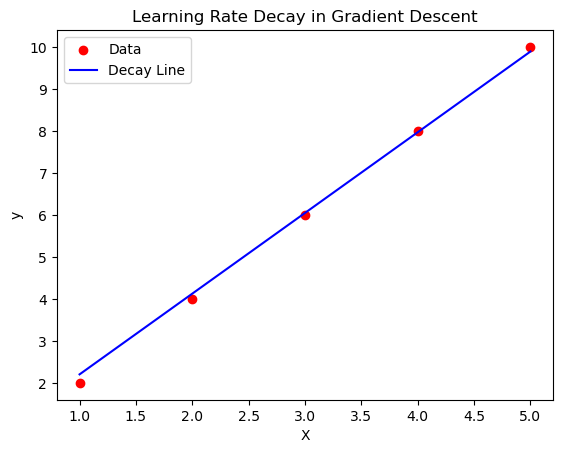

In [4]:
# Plot
plt.scatter(X, y, color='red', label='Data')
plt.plot(X, theta0 + theta1 * X, color='blue', label='Decay Line')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Learning Rate Decay in Gradient Descent")
plt.show()

# Gradient Clipping
Gradient Clipping — an essential trick, especially when training deep networks like RNNs or Transformers.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Data
X = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 6, 8, 10])

# Params
theta0 = 0
theta1 = 0
alpha = 0.1
iterations = 100
clip_value = 1.0  # Max allowed gradient norm

m = len(X)

def clip_gradients(g0, g1, threshold):
    norm = np.sqrt(g0**2 + g1**2)
    if norm > threshold:
        scale = threshold / norm
        g0 *= scale
        g1 *= scale
    return g0, g1

# Training loop
for i in range(iterations):
    prediction = theta0 + theta1 * X
    error = prediction - y

    # Gradients
    d_theta0 = (1/m) * np.sum(error)
    d_theta1 = (1/m) * np.sum(error * X)

    # Apply gradient clipping
    d_theta0, d_theta1 = clip_gradients(d_theta0, d_theta1, clip_value)

    # Update weights
    theta0 -= alpha * d_theta0
    theta1 -= alpha * d_theta1

    # Optional: print loss
    if i % 10 == 0:
        loss = np.mean((prediction - y) ** 2)
        print(f"Iter {i}: Loss = {loss:.4f}, Grad Norm = {np.sqrt(d_theta0**2 + d_theta1**2):.4f}")

print(f"\nFinal theta0: {theta0}, theta1: {theta1}")

Iter 0: Loss = 44.0000, Grad Norm = 1.0000
Iter 10: Loss = 10.2237, Grad Norm = 1.0000
Iter 20: Loss = 0.0428, Grad Norm = 0.1039
Iter 30: Loss = 0.0302, Grad Norm = 0.0715
Iter 40: Loss = 0.0215, Grad Norm = 0.0603
Iter 50: Loss = 0.0153, Grad Norm = 0.0508
Iter 60: Loss = 0.0109, Grad Norm = 0.0429
Iter 70: Loss = 0.0077, Grad Norm = 0.0361
Iter 80: Loss = 0.0055, Grad Norm = 0.0305
Iter 90: Loss = 0.0039, Grad Norm = 0.0257

Final theta0: 0.12354856025613167, theta1: 1.9657790299165863


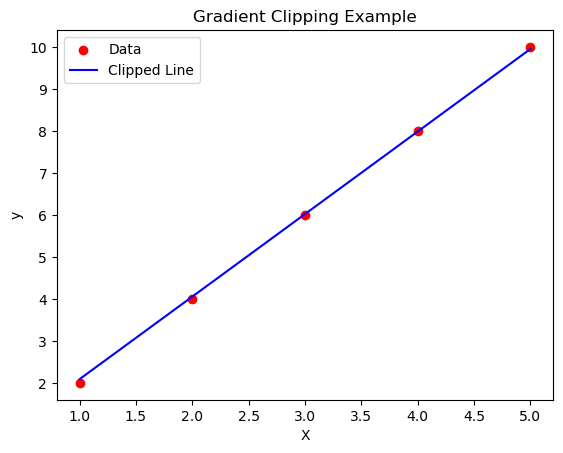

In [6]:
# Plot
plt.scatter(X, y, color='red', label='Data')
plt.plot(X, theta0 + theta1 * X, color='blue', label='Clipped Line')
plt.xlabel("X")
plt.ylabel("y")
plt.title("Gradient Clipping Example")
plt.legend()
plt.show()

# Minibatch Gradient Descent
Minibatch gradient descent computes updates using small random
subsets of data, balancing SGD’s noise and batch gradient descent’s stability. Mini-batch GD processes small chunks (mini-batches) of the data at a time — striking a great balance between speed and stability.It’s a hybrid between:

* Batch GD (uses entire dataset per update) — slow but stable

* Stochastic GD (uses 1 data point per update) — fast but noisy



In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Generate sample data
X = np.linspace(0, 10, 100)
y = 3 * X + 7 + np.random.randn(*X.shape) * 2  # y = 3x + 7 + noise

# Reshape for matrix operations
X = X.reshape(-1, 1)
y = y.reshape(-1, 1)

# Add bias term
X_b = np.c_[np.ones((len(X), 1)), X]  # shape: (n_samples, 2)

# Parameters
theta = np.zeros((2, 1))
alpha = 0.01
epochs = 50
batch_size = 16
m = len(X)

# Training loop
for epoch in range(epochs):
    # Shuffle the data at the start of each epoch
    indices = np.random.permutation(m)
    X_b_shuffled = X_b[indices]
    y_shuffled = y[indices]

    for i in range(0, m, batch_size):
        X_batch = X_b_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]

        # Compute gradients
        gradients = 2/batch_size * X_batch.T.dot(X_batch.dot(theta) - y_batch)

        # Update parameters
        theta -= alpha * gradients

    # Optional: loss tracking
    if epoch % 10 == 0:
        loss = np.mean((X_b.dot(theta) - y) ** 2)
        print(f"Epoch {epoch}: Loss = {loss:.4f}")

# Final parameters
print(f"\nTrained theta: {theta.ravel()}")

Epoch 0: Loss = 13.5546
Epoch 10: Loss = 9.4635
Epoch 20: Loss = 6.8099
Epoch 30: Loss = 5.8592
Epoch 40: Loss = 4.6400

Trained theta: [5.54645904 3.18433147]


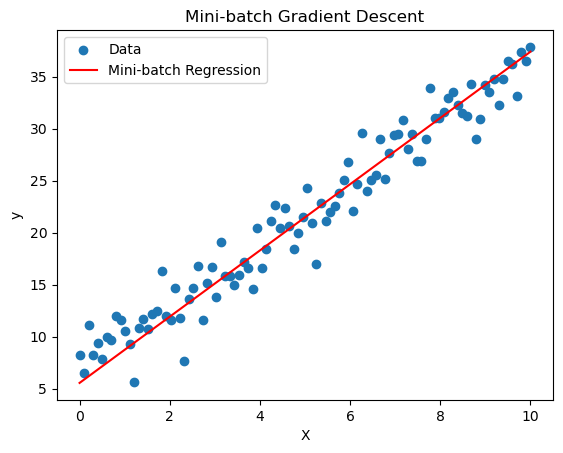

In [9]:
# Plotting
plt.scatter(X, y, label='Data')
plt.plot(X, X_b.dot(theta), color='red', label='Mini-batch Regression')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Mini-batch Gradient Descent")
plt.show()

# Coordinate Descent
Coordinate Descent is a simple yet powerful optimization algorithm, especially useful when your problem is high-dimensional and has a sparse solution (like in Lasso Regression).Coordinate Descent updates one parameter (coordinate) at a time, keeping the others fixed.

In [11]:
import numpy as np

# Generate data: y = 3x + 5
X = np.linspace(1, 10, 100).reshape(-1, 1)
y = 3 * X + 5 + np.random.randn(*X.shape) * 2  # Add noise

# Add bias column
X_b = np.c_[np.ones((len(X), 1)), X]  # shape: (100, 2)

# Initialize weights (theta0 = bias, theta1 = slope)
theta = np.random.randn(2, 1)

# Coordinate Descent parameters
epochs = 100
m = len(X)

# Coordinate Descent loop
for epoch in range(epochs):
    for j in range(2):  # Coordinate for each parameter
        # Prediction
        prediction = X_b.dot(theta)

        # Residual excluding current feature
        residual = prediction - X_b[:, j].reshape(-1, 1) * theta[j]

        # Closed-form solution for least squares update
        theta[j] = np.sum((y - residual) * X_b[:, j].reshape(-1, 1)) / np.sum(X_b[:, j] ** 2)

    # Optional loss print
    if epoch % 10 == 0:
        loss = np.mean((X_b.dot(theta) - y) ** 2)
        print(f"Epoch {epoch}: Loss = {loss:.4f}")

print(f"\nFinal theta (bias, weight): {theta.ravel()}")

Epoch 0: Loss = 20.5350
Epoch 10: Loss = 4.4694
Epoch 20: Loss = 4.2037
Epoch 30: Loss = 4.1993
Epoch 40: Loss = 4.1992
Epoch 50: Loss = 4.1992
Epoch 60: Loss = 4.1992
Epoch 70: Loss = 4.1992
Epoch 80: Loss = 4.1992
Epoch 90: Loss = 4.1992

Final theta (bias, weight): [4.53708486 3.09810229]
